In [2]:
#map acutal solar to the ISP 2026 file list


In [49]:

#get ISP files names for mapping
import time
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path
import datetime
import os



base = Path("C:/Users/BillNixey/OneDrive - Squadron Energy/Desktop/Working_files/New_model/mt_pasa/")


directory = Path(r"C:\Users\BillNixey\OneDrive - Squadron Energy\Desktop\Working_files\WF_correlation\2026_data_solar\solar_2019")
files = [f.name for f in directory.iterdir() if f.is_file()]
files = [f.removesuffix('_RefYear2019.csv') for f in files]
files = [x for x in files if "REZ" not in x and "Distribution" not in x and "Distributed" not in x]
#files
#len(files)
df = pd.DataFrame(files)
df.to_csv(base /'df_ISP_solar.csv',index=False)
#df

In [50]:
#get solar DUID info from NEO
now = datetime.datetime.now() 
s1 = str(now)
s2 = s1[:11]
s2 = s2.replace(":", "")
s2 = s2.replace(" ", "")

#add today's date to NEO extract
url2 = "https://www.neopoint.com.au/Service/Csv?f=107%20Information%5CPlantInformation&from="+s2+"%2000%3A00&period=Daily&instances=&section=-1&key=squnix77"

df_duid_data = pd.read_csv(url2)
df_duid_data = df_duid_data.rename(columns={"TransmissionLossFactor": "MLF"})
df_duid_data = df_duid_data[['DUID','STATIONNAME','REGIONID','MLF','FUEL','CAPACITY','STARTDATE']]
df_duid_data["FUEL"] = df_duid_data["FUEL"].str.replace(" ", "_", regex=False)
df_duid_data = df_duid_data[df_duid_data.FUEL.isin(['Solar'])]
df_duid_data.to_csv(base /'NEO_solar_names.csv',index=False)

#manually match to get solar_key_latest
#df_duid_data.head()

In [51]:
#add SCADA and UIGF actuals to solar key
import time
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path
import datetime
import os
from pathlib import Path
regions = ['NSW1','QLD1','SA1','VIC1'] #no Tas solar

base = Path("C:/Users/BillNixey/OneDrive - Squadron Energy/Desktop/Working_files/New_model/mt_pasa/")

#get actual maximum dipatched over the last 6 months
def get_actual_MWs():
    
    SF_maximums = []
    
    for region in regions:
        df = pd.read_csv(base /  f"actual_solar_Jan_month_scada/Solar+Generation+by+Region+per+DUID+5min+(Scada)+({region})(-2).csv")
        df = df.drop(columns=['DateTime'])
        df.columns = df.columns.str.replace(' MW', '', regex=False)
        summary = df.max().reset_index()
        summary.columns = ['DUID', 'SCADA_MAX_MW']
        SF_maximums.append(summary)
    result = pd.concat(SF_maximums)
    return result

def get_UIGF_MWs():
    
    WF_maximums = []
    
    for region in regions:
        df = pd.read_csv(base /  f"UIGF/Region+UIGF+per+DUID+5min+({region})(-2).csv")
        df = df.drop(columns=['DateTime'])
        df.columns = df.columns.str.replace(' UIGF',"", regex=False)
        summary = df.max().reset_index()
        summary.columns = ['DUID', 'UIGF_MAX_MW']
        WF_maximums.append(summary)
    result = pd.concat(WF_maximums)
    return result

df_key = pd.read_csv(base /'solar_key_latest.csv')

result = get_actual_MWs()
df_key = pd.merge(df_key,result,on='DUID',how='left')

result2 = get_UIGF_MWs()
df_key = pd.merge(df_key,result2,on='DUID',how='left')

df_key["SCADA_MAX_MW"] = df_key["SCADA_MAX_MW"].fillna(df_key["CAPACITY"])

df_key.reset_index(drop=True).to_csv(base /'solar_key_latest_SCADA_UIGF.csv',index=False)
df_key.head(20)



,ISP NAME,STATIONNAME,REGIONID,MLF,FUEL,CAPACITY,STARTDATE,DUID,SCADA_MAX_MW,UIGF_MAX_MW
0,Adelaide_Desal_FFP,Adelaide Desalination Plant Solar,SA1,1.0037,Solar,19,20/04/2021 0:00,ADPPV1,0.00600,19.00000
1,Aldoga_SAT,Aldoga Solar Farm,QLD1,0.9318,Solar,387,17/03/2025 0:00,ALDGASF1,388.71039,387.00000
2,Avonlie_SAT,Avonlie Solar Farm,NSW1,0.8698,Solar,190,28/03/2023 0:00,AVLSF1,189.99565,189.99400
3,Bannerton_SAT,Bannerton Solar Park,VIC1,0.8986,Solar,88,11/07/2018 0:00,BANN1,87.61000,88.00000
4,Beryl_SAT,Beryl Solar Farm,NSW1,0.9284,Solar,87,11/04/2019 0:00,BERYLSF1,87.00000,87.00000
5,Bluegrass_SAT,Blue Grass Solar Farm,QLD1,0.9543,Solar,148,1/02/2022 0:00,BLUEGSF1,124.32140,131.43600
6,Bolivar_FFP,Bolivar Waste Water Treatment Plant PV,SA1,0.9999,Solar,6,16/11/2021 0:00,BOWWPV1,6.32700,6.02600
7,Bomen_SAT,Bomen Solar Farm,NSW1,0.9187,Solar,100,17/03/2020 0:00,BOMENSF1,85.19112,98.86200
8,Broadsound_SAT,Broadsound Energy Park,QLD1,0.9290,Solar,296,24/12/2025 0:00,BRDDSF01,3.22876,257.06760
9,Broken_Hill_FFP,Broken Hill Solar Plant,NSW1,0.8642,Solar,53,25/08/2015 0:00,BROKENH1,53.49918,53.29919


In [53]:
#extract solar data for multiple reference years

import os
import pandas as pd
from itertools import combinations
from pathlib import Path
import time

start = time.time()

base2 = Path("C:/Users/BillNixey/OneDrive - Squadron Energy/Desktop/Working_files/WF_correlation/2026_data_solar/")

# load solar key
df_key = pd.read_csv(base /'solar_key_latest_SCADA_UIGF.csv')

# Replace "Not available" file names with the largets regional solar farm
region_to_isp = (
    df_key[df_key["ISP NAME"] != "Not available"]
    .sort_values("CAPACITY", ascending=False)
    .drop_duplicates("REGIONID")
    .set_index("REGIONID")["ISP NAME"]
)

mask = df_key["ISP NAME"] == "Not available"
df_key.loc[mask, "ISP NAME"] = (df_key.loc[mask, "REGIONID"].map(region_to_isp))
df_key = df_key.sort_values(by="ISP NAME", ascending=True)
#df_key.to_csv(base / 'test.csv')

REF_YEARS=list(range(2019, 2026))

my_discount = {'NSW1': 0.75,'QLD1':0.95,'SA1':1,'TAS1':1,'VIC1':0.75}

results = [] 

for REF_YEAR in REF_YEARS:
    print("")
    print("Solving", REF_YEAR)
    file_list = list(df_key['ISP NAME'])
    file_list = [f + '_RefYear'+str(REF_YEAR)+'.csv' for f in file_list]
            
    for i in list(df_key.index):
        print(".", end='.')
        s1 = 'solar_'+str(REF_YEAR)
        df1 = pd.read_csv(base2 / s1 / file_list[i])
        df1 = pd.melt(df1, id_vars=['Year','Month','Day'],value_vars=[str(i) for i in range(1, 49)],var_name='Interval',value_name='GEN')
        base_date = pd.to_datetime(df1[["Year", "Month", "Day"]])
        intervals = df1["Interval"].astype(int)
        df1["INTERVAL_DATETIME"] = base_date + pd.to_timedelta(intervals * 30, unit="min")
        df1['DUID'] = df_key['DUID'][i]
        df1['REGIONID'] = df_key.REGIONID[i]
        df1['MW'] = df1['GEN'] * df_key.SCADA_MAX_MW[i] *my_discount[df_key.REGIONID[i]] #discount factor
        df1['REF_YEAR'] = REF_YEAR
        df2=df1[(df1.Year == 2026)] 
        df2 = df2[['INTERVAL_DATETIME','Day','Month','Year','DUID','REGIONID','MW','REF_YEAR']]
        results.append(df2)   

df_out = pd.concat(results)

df_out = df_out.sort_values(by=["DUID","INTERVAL_DATETIME"],ascending=True).reset_index(drop=True)


df_out.to_parquet(base /"ISP_solar_2026_x7.parquet", index=False)

end = time.time()
print(f"✅ Processing complete in {end - start:.2f} seconds")
#df_out.to_csv('test.csv')




Solving 2019
..........................................................................................................................................................................................................................................
Solving 2020
..........................................................................................................................................................................................................................................
Solving 2021
..........................................................................................................................................................................................................................................
Solving 2022
..........................................................................................................................................................................................................................................
Solving

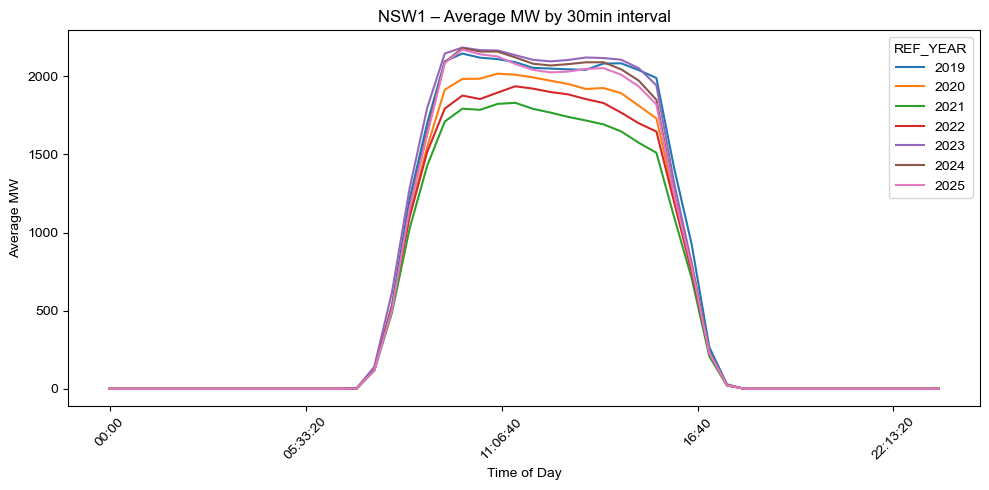

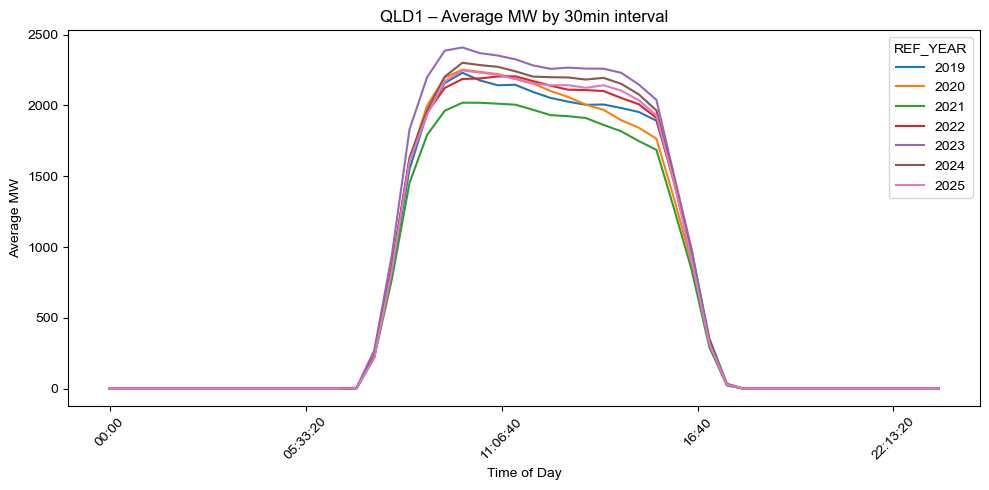

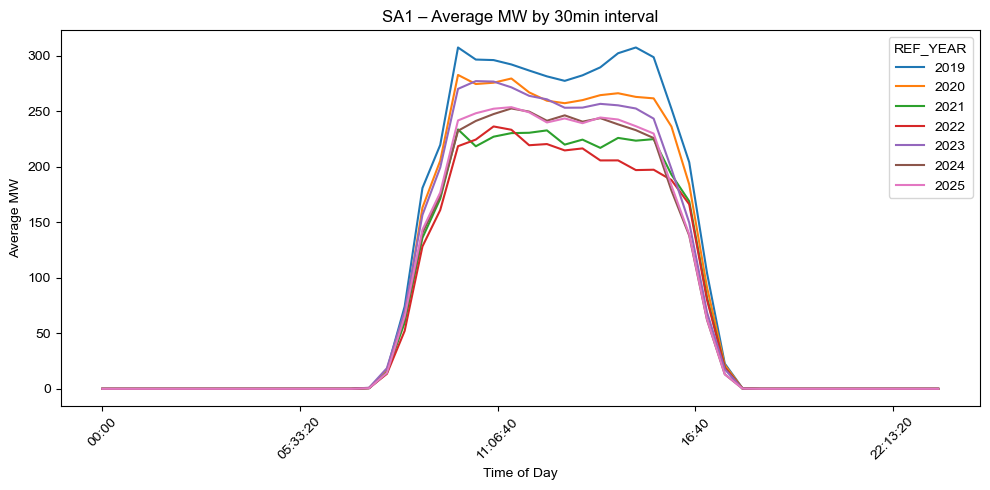

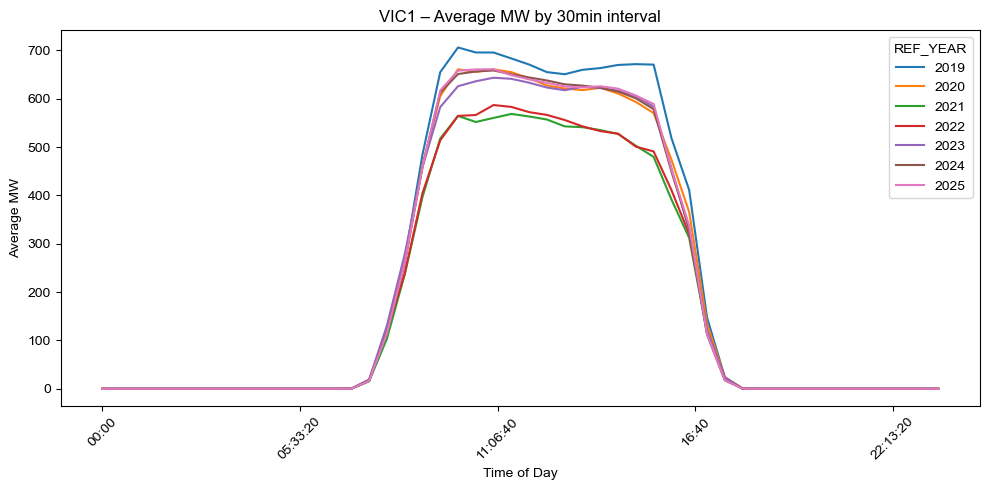

In [54]:
#check solar trace shape
import pandas as pd
import matplotlib.pyplot as plt


from pathlib import Path
base = Path("C:/Users/BillNixey/OneDrive - Squadron Energy/Desktop/Working_files/New_model/mt_pasa/")
df = pd.read_parquet(base / "ISP_solar_2026_x7.parquet")

# ensure datetime
df['INTERVAL_DATETIME'] = pd.to_datetime(df['INTERVAL_DATETIME'])
#only June
df = df[df["INTERVAL_DATETIME"].dt.month == 6].copy()

# aggregate
agg = (
    df.groupby(['REGIONID', 'REF_YEAR','INTERVAL_DATETIME'], as_index=False)['MW']
      .sum()
)

# create 30‑min time-of-day (keeps ordering correct)
agg['TIME_30MIN'] = agg['INTERVAL_DATETIME'].dt.floor('30min').dt.time

agg = (
    agg.groupby(['REGIONID', 'REF_YEAR','TIME_30MIN'], as_index=False)['MW']
      .mean()
)


# sort time for clean plotting
agg = agg.sort_values('TIME_30MIN')

# plot: one chart per region
for region, g in agg.groupby('REGIONID'):
    pivot = g.pivot(index='TIME_30MIN', columns='REF_YEAR', values='MW')
    
    plt.figure(figsize=(10, 5))
    pivot.plot(ax=plt.gca())
    
    plt.title(f'{region} – Average MW by 30min interval')
    plt.xlabel('Time of Day')
    plt.ylabel('Average MW')
    plt.xticks(rotation=45)
    plt.legend(title='REF_YEAR')
    plt.tight_layout()
    plt.show()
    

In [55]:
#check total annual volumes versus the UIGF

import pandas as pd
import matplotlib.pyplot as plt


from pathlib import Path
base = Path("C:/Users/BillNixey/OneDrive - Squadron Energy/Desktop/Working_files/New_model/mt_pasa/")
df = pd.read_parquet(base / "ISP_solar_2026_x7.parquet")


monthly_mw = (
    df.assign(Month=df["INTERVAL_DATETIME"].dt.to_period("M"))
      .groupby(["Month", "REF_YEAR", "REGIONID"], as_index=False)["MW"]
      .sum()
)
monthly_mw['GWh'] = monthly_mw['MW'] /2000
print("ISP traces:")
#monthly_mw[(monthly_mw.REGIONID == 'NSW1') & (monthly_mw.Month == '2026-03')]

df_key = pd.read_csv(base /'solar_key_latest_SCADA_UIGF.csv')



regions = ['NSW1','QLD1','SA1','VIC1'] 
def get_UIGF_MWs():
    
    WF_sums = []
    
    for region in regions:
        print(region)
        df_key2 = df_key[df_key.REGIONID == region]
        my_NMIs = list(df_key2.DUID)
        df = pd.read_csv(base /  f"UIGF/Region+UIGF+per+DUID+5min+({region})(-2).csv")
        df["DateTime"] = pd.to_datetime(df["DateTime"])
        
        df.columns = df.columns.str.replace(' UIGF',"", regex=False)
        df = df[["DateTime"]+my_NMIs]
        my_cols = df.columns.drop("DateTime").tolist()
        df = (df.assign(Month=df["DateTime"].dt.to_period("M"),Total=df[my_cols].sum(axis=1))
            .groupby("Month", as_index=False)["Total"]
            .sum())
        df["REGIONID"] = region
        df['UIGF_GWh'] = df['Total']/12000
        df = df[['REGIONID','Month', 'UIGF_GWh']]
        WF_sums.append(df)
    result = pd.concat(WF_sums)
    return result
print('actual UIGF')
temp = get_UIGF_MWs()
df0 = pd.merge(monthly_mw,temp,on=['REGIONID','Month'],how='inner')#.to_csv(base / 'monthly_compare_solar.csv',index = False)
df0.head()

ISP traces:
actual UIGF
NSW1
QLD1
SA1
VIC1


,Month,REF_YEAR,REGIONID,MW,GWh,UIGF_GWh
0,2026-01,2019,NSW1,2.125504e+06,1062.752185,1342.692189
1,2026-01,2019,QLD1,1.958644e+06,979.321792,762.641307
2,2026-01,2019,SA1,3.256522e+05,162.826075,156.048581
3,2026-01,2019,VIC1,7.002524e+05,350.126217,405.891337
4,2026-01,2020,NSW1,2.033126e+06,1016.562764,1342.692189


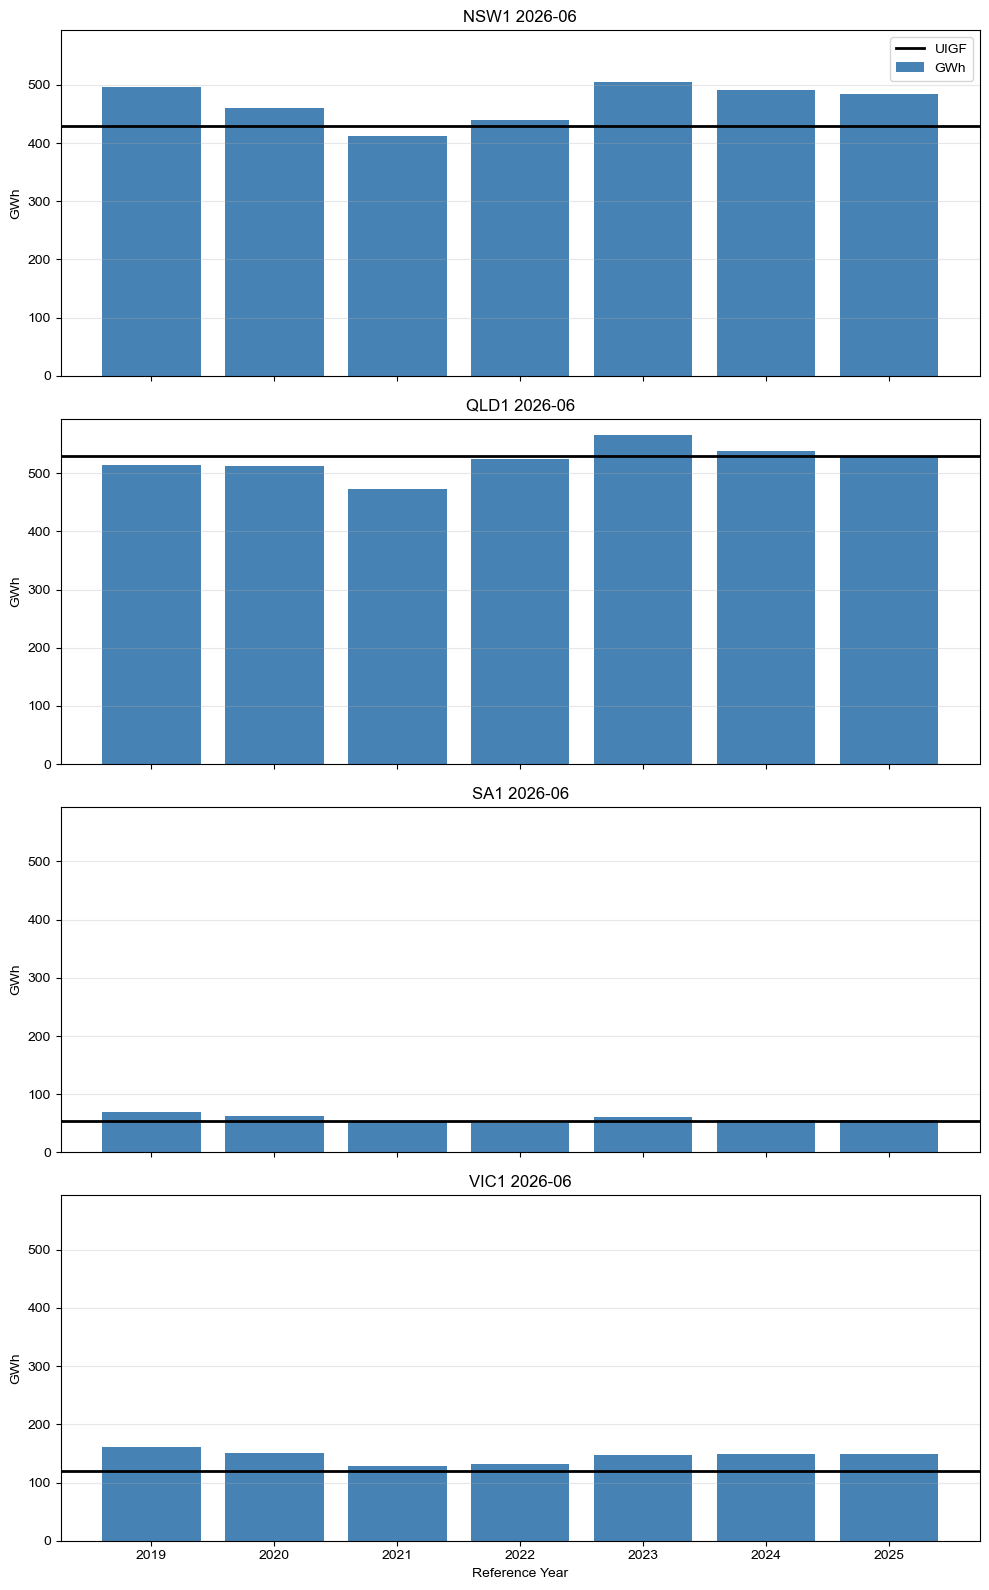

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

my_month = '2026-06'

df = df0[df0.Month == my_month]

# Ensure REF_YEAR is sorted
df = df.sort_values(["REGIONID", "REF_YEAR"])

regions = df["REGIONID"].unique()

fig, axes = plt.subplots(
    nrows=len(regions),
    figsize=(10, 4 * len(regions)),
    sharex=True,
    sharey=True
)

# If only one region, make axes iterable
if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    region_df = df[df["REGIONID"] == region]

    # Bar chart of GWh by reference year
    ax.bar(
        region_df["REF_YEAR"].astype(str),
        region_df["GWh"],
        color="steelblue",
        label="GWh"
    )

    # Horizontal UIGF line
    uigf = region_df["UIGF_GWh"].iloc[0]
    ax.axhline(
        uigf,
        color="black",
        linewidth=2,
        label="UIGF"
    )

    ax.set_title(region+" "+my_month)
    ax.set_ylabel("GWh")
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xlabel("Reference Year")

# Only show legend once
axes[0].legend()

plt.tight_layout()
plt.show()

In [42]:
#compare NSW and VIC  UIGF by DUID. check why ISP is so much higher than UIGF actual solar for June and May 2026.

import pandas as pd
import matplotlib.pyplot as plt


from pathlib import Path
'''
base = Path("C:/Users/BillNixey/OneDrive - Squadron Energy/Desktop/Working_files/New_model/mt_pasa/")
df = pd.read_parquet(base / "ISP_solar_2026_x7.parquet")


monthly_mw = (
    df.assign(Month=df["INTERVAL_DATETIME"].dt.to_period("M"))
      .groupby(["Month", "REF_YEAR", "REGIONID","DUID"], as_index=False)["MW"]
      .sum()
)
monthly_mw['GWh'] = monthly_mw['MW'] /2000
print("ISP traces:")
'''

#df_key = pd.read_csv(base /'solar_key_latest.csv')

region = 'VIC1'#,'QLD1','SA1','VIC1'] 

WF_sums = []
    
   
print(region)
df_key2 = df_key[df_key.REGIONID == region]
my_NMIs = list(df_key2.DUID)
df = pd.read_csv(base /  f"UIGF/Region+UIGF+per+DUID+5min+({region})(-2).csv")

df.columns = df.columns.str.replace(' UIGF',"", regex=False)

df["DateTime"] = pd.to_datetime(df["DateTime"])

# Convert from wide to long
long_df = df.melt(id_vars="DateTime",var_name="DUID",value_name="MW")

# Create month column (choose the format you want)
long_df["Month"] = long_df["DateTime"].dt.to_period("M").astype(str)

# Group and calculate GWh
result = (long_df.groupby(["Month", "DUID"], as_index=False)["MW"].sum())

result["UIGF_GWh"] = result["MW"] / 12000

#result = pd.merge(result, df_key, on='DUID',how='inner')

result = result[['DUID','Month', 'UIGF_GWh']]
result["Month"] = pd.PeriodIndex(result["Month"], freq="M")

df0 = pd.merge(monthly_mw,result,on=['DUID','Month'],how='inner')#.to_csv(base / 'monthly_compare_solar.csv',index = False)
df0[(df0.REF_YEAR == 2023) & (df0.Month == '2026-06') ].to_csv(base / 'test.csv')
print('done')

VIC1
done


In [43]:
#view annual total volumes by region

import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"
# Pivot regions into columns

df_region_year2 = df_region_year[df_region_year.REGIONID.isin(['NSW1','VIC1','QLD1','SA1'])]
 
df_pivot = df_region_year2.pivot(
    index="REF_YEAR",
    columns="REGIONID",
    values="TWh"
)

# Rank years by total TWh
df_pivot["Total"] = df_pivot.sum(axis=1)
df_pivot = df_pivot.sort_values("Total", ascending=True)

# Remove helper column
df_plot = df_pivot.drop(columns="Total")

region_colors = {
    "NSW1": "#AED137",  # blue
    "QLD1": "#021051",  # orange
    "SA1": "#2ca02c",   # green
    "TAS1": "#d62728",  # red
    "VIC1": "#BFE7FB"   # purple
}

colors = [region_colors[col] for col in df_plot.columns]


# Plot
ax = df_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6),color=colors
)

ax.set_xlabel("TWh")
ax.set_ylabel("Reference Year")
ax.set_title("NEM solar generation by region and ISP Reference Year (cal 2026 basis)")

plt.tight_layout()
plt.show()

NameError: name 'df_region_year' is not defined